In [7]:
# 1 CARGA DE DATOS
import pandas as pd

# Cargar dataset limpio y validado del Notebook 03
df_corregida = pd.read_csv("../1_data/processed/df_corregida.csv")

print("Variables proxy creadas correctamente")
# Confirmo primeras filas
print("Dataset cargado correctamente")
df_corregida.head()

Variables proxy creadas correctamente
Dataset cargado correctamente


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
# ariable Proxy 1: Riesgo de Burnout
df_corregida['burnout_risk'] = ((df_corregida['WorkLifeBalance'] <= 2) & (df_corregida['JobInvolvement'] <= 2)).astype(int)
   
    # Variable Proxy 2: Cultura Positiva
df_corregida['cultura_positiva'] = ((df_corregida['EnvironmentSatisfaction'] + df_corregida['RelationshipSatisfaction']) >= 6).astype(int)

    # Variable Proxy 3: Alto Engagement
df_corregida['alto_engagement'] = ((df_corregida['JobInvolvement'] >= 3) & (df_corregida['PerformanceRating'] >= 3)).astype(int)

    # Variable Proxy 4: Oportunidades de Desarrollo
df_corregida['oportunidades_desarrollo'] = ((df_corregida['TrainingTimesLastYear'] >= 2) & (df_corregida['YearsInCurrentRole'] <= 3)).astype(int)

    # Revisar que las distribuciones tengan sentido
print("Distribuciones Variables Proxy:")
print(f"Burnout Risk:\n{df_corregida['burnout_risk'].value_counts(normalize=True)}\n")
print(f"Cultura Positiva:\n{df_corregida['cultura_positiva'].value_counts(normalize=True)}\n")
print(f"Alto Engagement:\n{df_corregida['alto_engagement'].value_counts(normalize=True)}\n")
print(f"Oportunidades Desarrollo:\n{df_corregida['oportunidades_desarrollo'].value_counts(normalize=True)}\n")

Distribuciones Variables Proxy:
Burnout Risk:
burnout_risk
0    0.914966
1    0.085034
Name: proportion, dtype: float64

Cultura Positiva:
cultura_positiva
0    0.502721
1    0.497279
Name: proportion, dtype: float64

Alto Engagement:
alto_engagement
1    0.688435
0    0.311565
Name: proportion, dtype: float64

Oportunidades Desarrollo:
oportunidades_desarrollo
1    0.502721
0    0.497279
Name: proportion, dtype: float64



In [ ]:
# Validación de calidad tras creación de variables proxy

# Reviso dimensiones
df_corregida.shape  

# Valores nulos
df_corregida.isnull().sum().sum()

# Duplicados
df_corregida.duplicated().sum()

# Estadísticas básicas
df_corregida.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


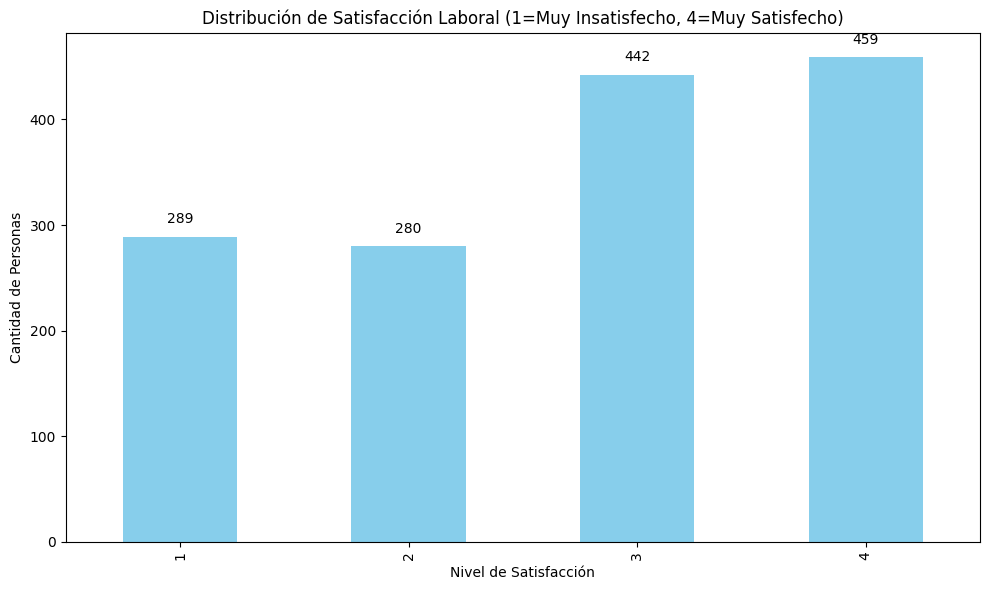

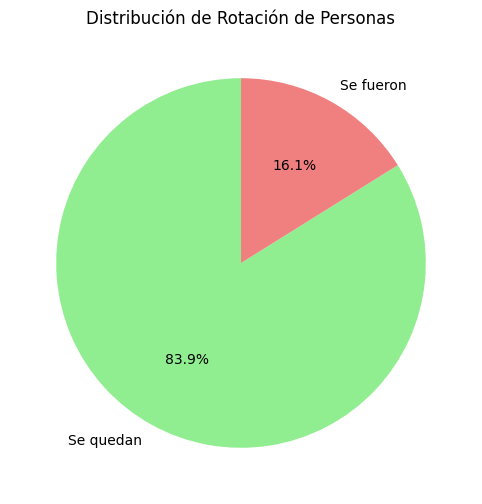

INSIGHT: 237 personas se fueron (16.1%)


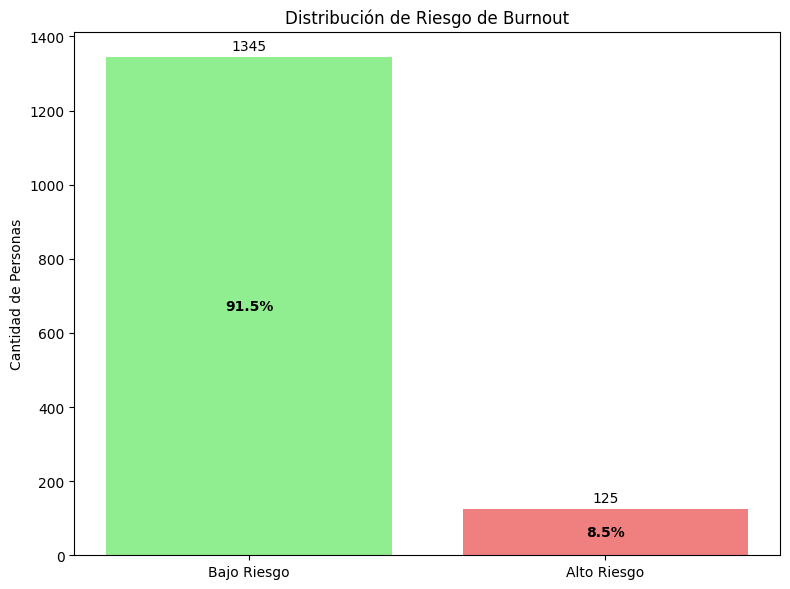

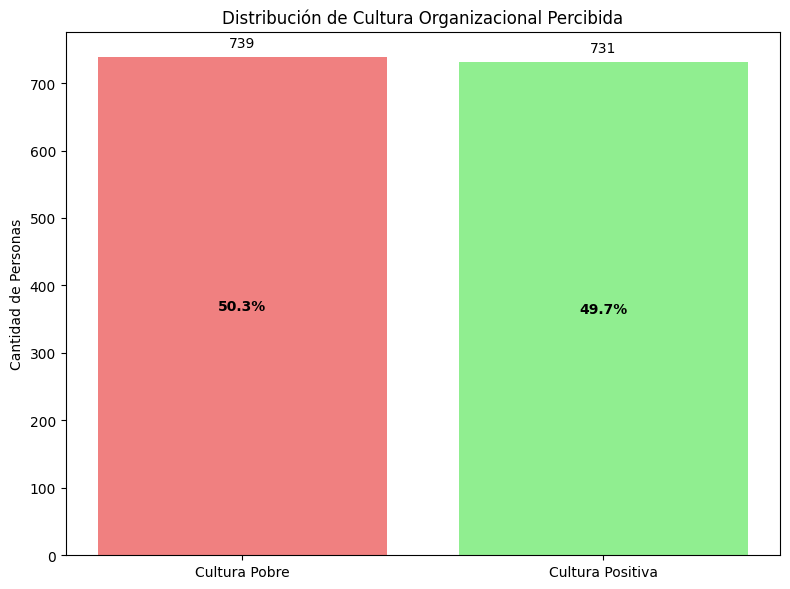

In [ ]:
# Análisis univariante (cada variable por separado)
import matplotlib.pyplot as plt

    # Gráfico 1: Distribución de Satisfacción Laboral
plt.figure(figsize=(10, 6))
df_corregida['JobSatisfaction'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución de Satisfacción Laboral (1=Muy Insatisfecho, 4=Muy Satisfecho)')
plt.xlabel('Nivel de Satisfacción')
plt.ylabel('Cantidad de Personas')
for i, v in enumerate(df_corregida['JobSatisfaction'].value_counts().sort_index()):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

    # Gráfico 2: Distribución de Rotación (Attrition)
plt.figure(figsize=(8, 6))
attrition_counts = df_corregida['Attrition'].value_counts()
colors = ['lightgreen', 'lightcoral']
plt.pie(attrition_counts.values, labels=['Se quedan', 'Se fueron'], autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribución de Rotación de Personas')
plt.show()
print(f"INSIGHT: {attrition_counts[1]} personas se fueron ({attrition_counts[1]/len(df_corregida)*100:.1f}%)")

    # Gráfico 3: Distribución de Burnout Risk
plt.figure(figsize=(8, 6))
burnout_counts = df_corregida['burnout_risk'].value_counts()
plt.bar(['Bajo Riesgo', 'Alto Riesgo'], burnout_counts.values, color=['lightgreen', 'lightcoral'])
plt.title('Distribución de Riesgo de Burnout')
plt.ylabel('Cantidad de Personas')
for i, v in enumerate(burnout_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
    porcentaje = (v / len(df_corregida)) * 100
    plt.text(i, v/2, f'{porcentaje:.1f}%', ha='center', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

    # Gráfico 4: Distribución de Cultura Positiva
plt.figure(figsize=(8, 6))
cultura_counts = df_corregida['cultura_positiva'].value_counts()
plt.bar(['Cultura Pobre', 'Cultura Positiva'], cultura_counts.values, color=['lightcoral', 'lightgreen'])
plt.title('Distribución de Cultura Organizacional Percibida')
plt.ylabel('Cantidad de Personas')
for i, v in enumerate(cultura_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
    porcentaje = (v / len(df_corregida)) * 100
    plt.text(i, v/2, f'{porcentaje:.1f}%', ha='center', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Resumen univariante - Hallazgos 

print("RESUMEN UNIVARIANTE")

resumen_univariante = {
    'Satisfacción Laboral': f"Promedio: {df_corregida['JobSatisfaction'].mean():.2f}/4",
    'Rotación': f"{df_corregida['Attrition'].sum()} empleados se fueron ({df_corregida['Attrition'].mean()*100:.1f}%)",
    'Burnout Risk': f"{df_corregida['burnout_risk'].sum()} empleados en riesgo ({df_corregida['burnout_risk'].mean()*100:.1f}%)",
    'Cultura Positiva': f"{df_corregida['cultura_positiva'].sum()} empleados la perciben ({df_corregida['cultura_positiva'].mean()*100:.1f}%)",
    'Formación': f"Promedio: {df_corregida['TrainingTimesLastYear'].mean():.1f} entrenamientos/año"
}

for variable, resumen in resumen_univariante.items():
    print(f"• {variable}: {resumen}")


RESUMEN UNIVARIANTE
• Satisfacción Laboral: Promedio: 2.73/4
• Rotación: 237 empleados se fueron (16.1%)
• Burnout Risk: 125 empleados en riesgo (8.5%)
• Cultura Positiva: 731 empleados la perciben (49.7%)
• Formación: Promedio: 2.8 entrenamientos/año


In [ ]:
# Análisis de Attrition con variables proxy
# Creo variables categóricas con nombres  
df_corregida['Attrition_cat'] = df_corregida['Attrition'].map({0: 'Se quedan', 1: 'Se fueron'})
df_corregida['burnout_risk_cat'] = df_corregida['burnout_risk'].map({0: 'Bajo Riesgo', 1: 'Alto Riesgo'})
df_corregida['cultura_positiva_cat'] = df_corregida['cultura_positiva'].map({0: 'Cultura Pobre', 1: 'Cultura Positiva'})
df_corregida['alto_engagement_cat'] = df_corregida['alto_engagement'].map({0: 'Bajo Engagement', 1: 'Alto Engagement'})
df_corregida['oportunidades_desarrollo_cat'] = df_corregida['oportunidades_desarrollo'].map({0: 'Sin Oportunidades', 1: 'Con Oportunidades'})
df_corregida['OverTime_cat'] = df_corregida['OverTime'].map({0: 'Sin Horas Extras', 1: 'Con Horas Extras'})

# Defino qué relaciones quiero analizar
relaciones_hipotesis = [
    ('burnout_risk_cat', 'Attrition_cat', 'Burnout vs Rotación'),
    ('cultura_positiva_cat', 'Attrition_cat', 'Cultura Positiva vs Rotación'),
    ('alto_engagement_cat', 'Attrition_cat', 'Engagement vs Rotación'),
    ('oportunidades_desarrollo_cat', 'Attrition_cat', 'Oportunidades vs Rotación'),
    ('OverTime_cat', 'Attrition_cat', 'Horas Extras vs Rotación'),
    ('JobSatisfaction', 'Attrition_cat', 'Satisfacción Laboral vs Rotación'),   
    ('WorkLifeBalance', 'Attrition_cat', 'Equilibrio vs Rotación')   
]

# Lista para guardar resultados
resultados = []

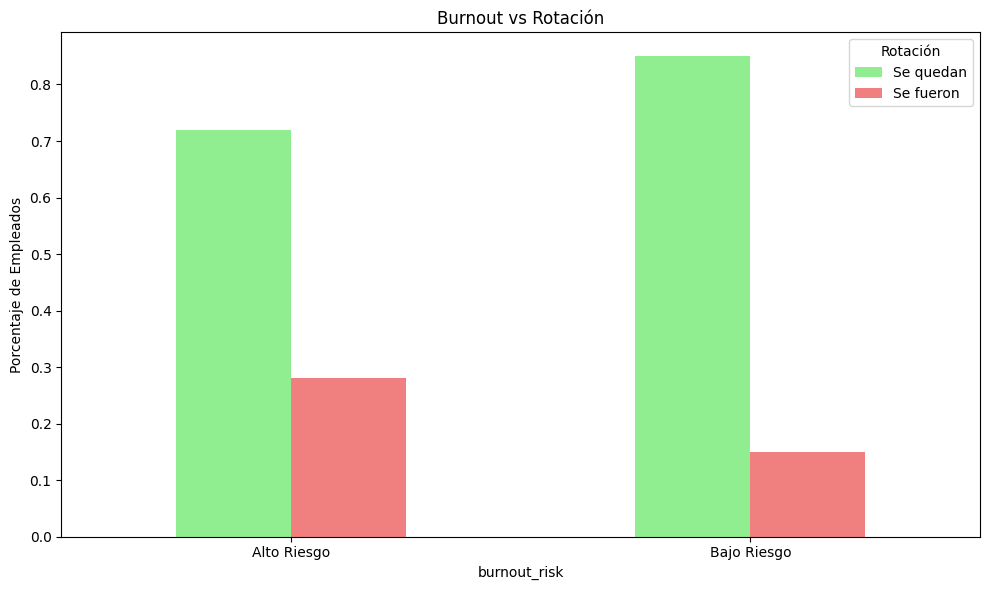


📈 Burnout vs Rotación:
   • Alto Riesgo: 28.0% se van
   • Bajo Riesgo: 15.0% se van
--------------------------------------------------


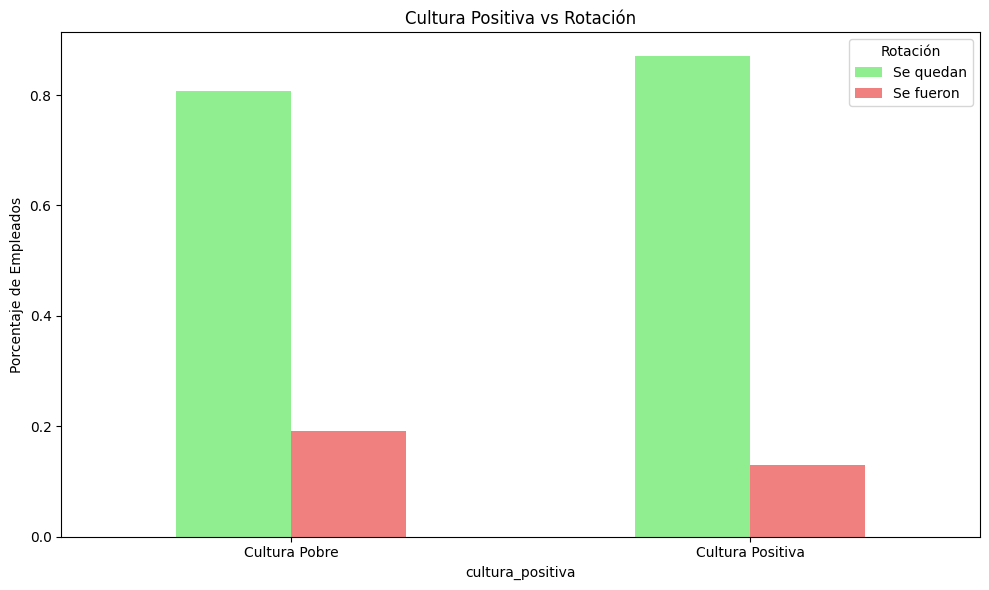


📈 Cultura Positiva vs Rotación:
   • Cultura Pobre: 19.2% se van
   • Cultura Positiva: 13.0% se van
--------------------------------------------------


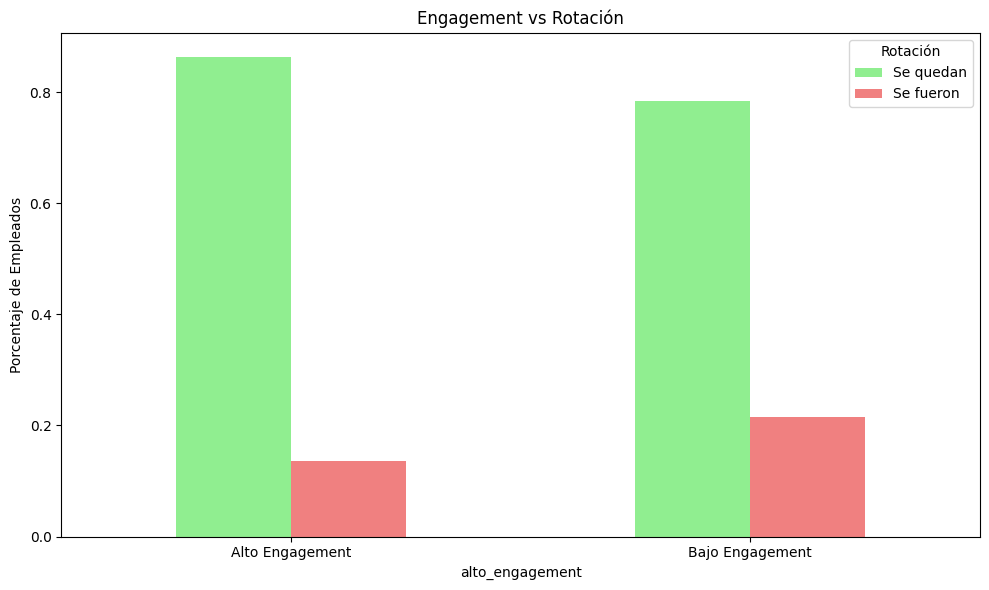


📈 Engagement vs Rotación:
   • Alto Engagement: 13.6% se van
   • Bajo Engagement: 21.6% se van
--------------------------------------------------


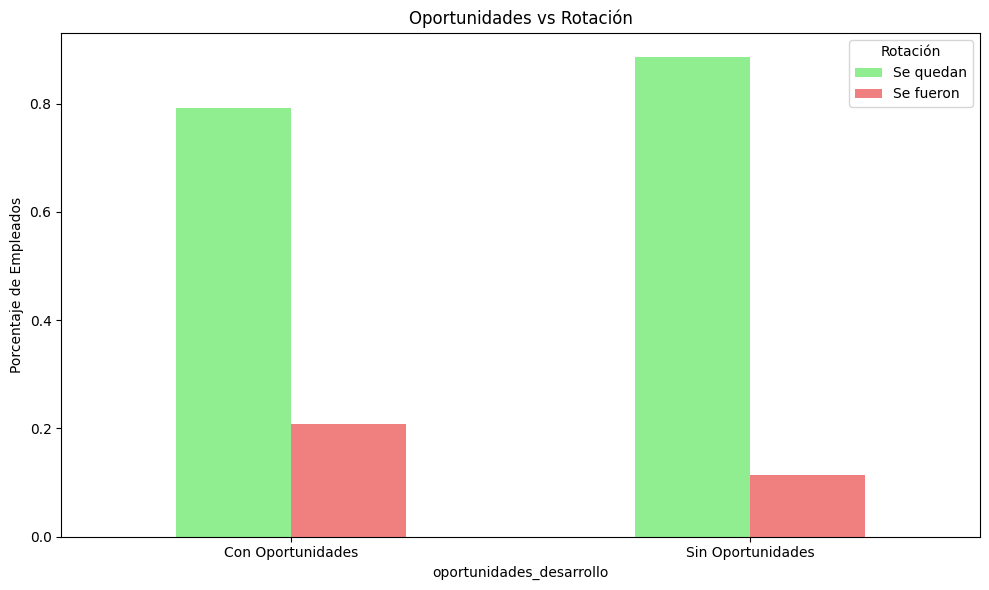


📈 Oportunidades vs Rotación:
   • Con Oportunidades: 20.8% se van
   • Sin Oportunidades: 11.4% se van
--------------------------------------------------


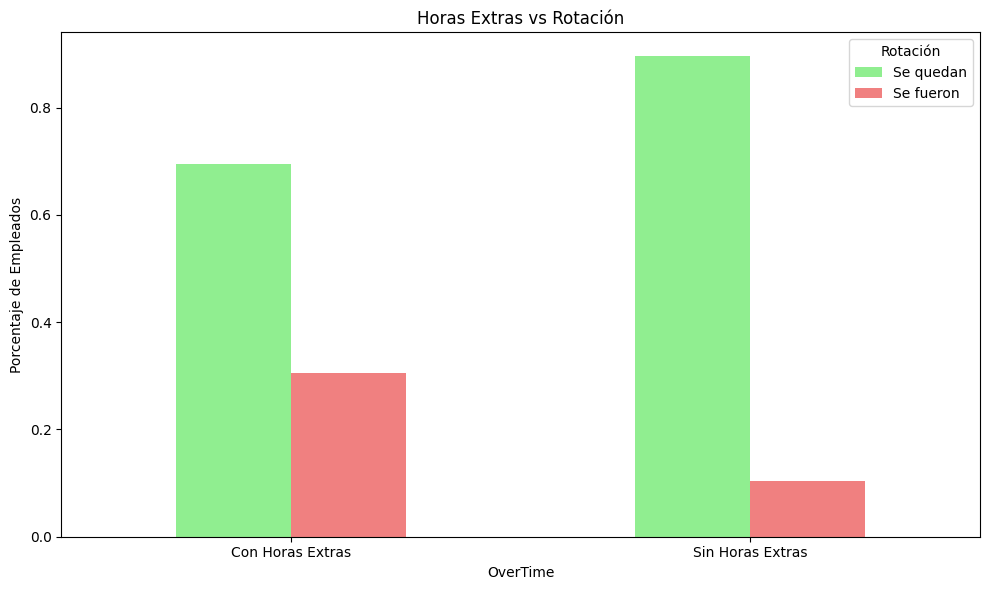


📈 Horas Extras vs Rotación:
   • Con Horas Extras: 30.5% se van
   • Sin Horas Extras: 10.4% se van
--------------------------------------------------


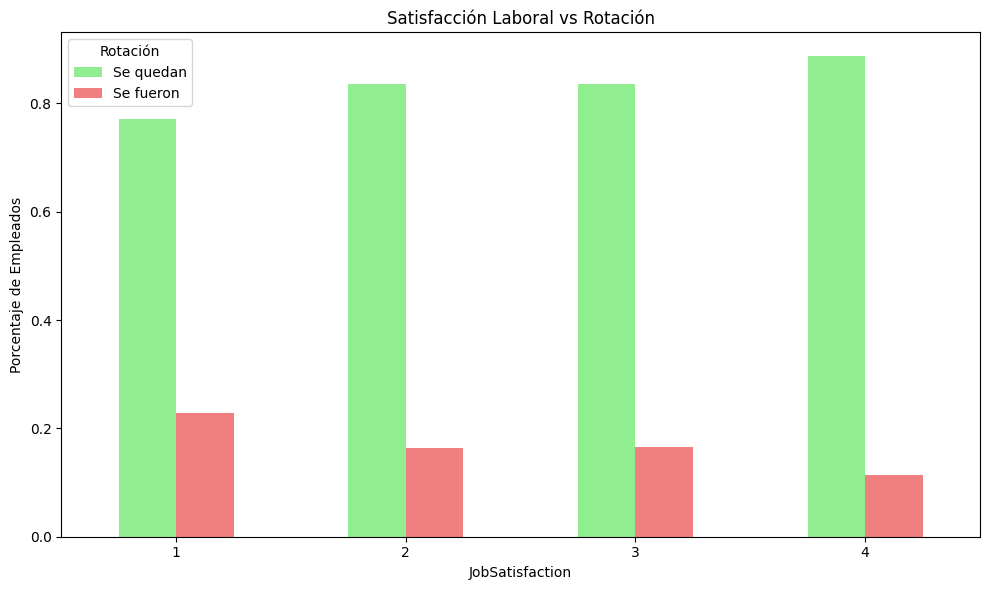


📈 Satisfacción Laboral vs Rotación:
   • 1: 22.8% se van
   • 2: 16.4% se van
   • 3: 16.5% se van
   • 4: 11.3% se van
--------------------------------------------------


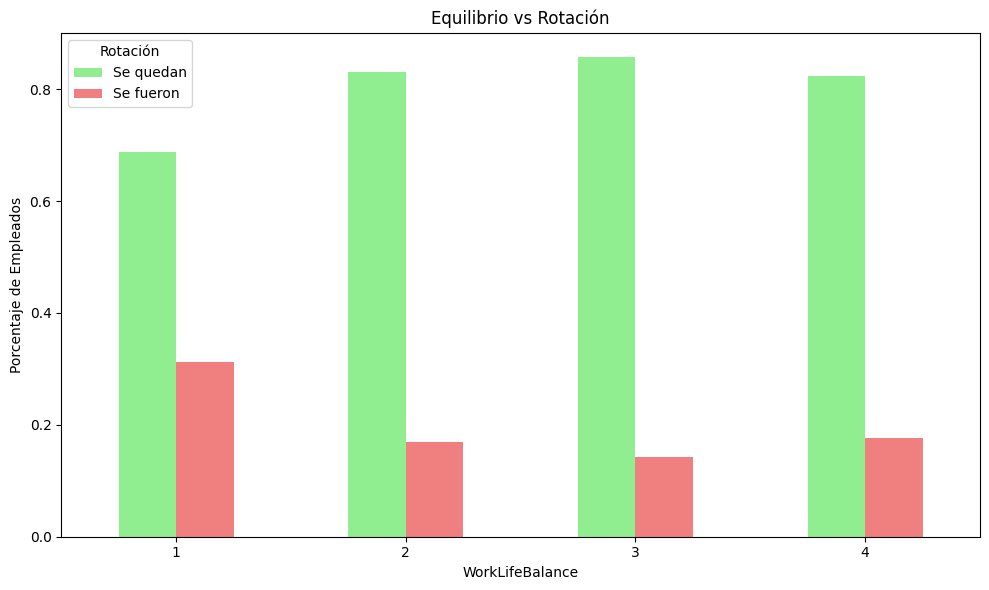


📈 Equilibrio vs Rotación:
   • 1: 31.2% se van
   • 2: 16.9% se van
   • 3: 14.2% se van
   • 4: 17.6% se van
--------------------------------------------------


In [ ]:
for var1, var2, titulo in relaciones_hipotesis:
    # Calculo tabla de contingencia
    counts = pd.crosstab(df_corregida[var1], df_corregida[var2], normalize='index')
    
    # Aseguro orden correcto de columnas
    if var2 == 'Attrition_cat':
        if 'Se quedan' in counts.columns and 'Se fueron' in counts.columns:
            counts = counts[['Se quedan', 'Se fueron']]
    
    # Guardo datos clave para el resumen
    if 'Se fueron' in counts.columns:
        max_rotacion = counts['Se fueron'].max()
        categoria_max = counts['Se fueron'].idxmax()
        min_rotacion = counts['Se fueron'].min()
        categoria_min = counts['Se fueron'].idxmin()
        
        resultados.append({
            'hipotesis': titulo,
            'variable': var1,
            'categoria_alto_riesgo': categoria_max,
            'rotacion_alto': max_rotacion,
            'categoria_bajo_riesgo': categoria_min,
            'rotacion_bajo': min_rotacion
        })
    
    # Creo gráfico 
    colores = ['lightgreen', 'lightcoral'] if var2 == 'Attrition_cat' else ['lightblue', 'lightpink']
    
    ax = counts.plot(kind='bar', figsize=(10,6), color=colores)
    ax.set_title(titulo)
    ax.set_xlabel(var1.replace('_cat', ''))
    ax.set_ylabel('Porcentaje de Empleados')
    ax.legend(title='Rotación')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Muestro datos del gráfico actual
    print(f"\n📈 {titulo}:")
    for categoria in counts.index:
        rotacion = counts.loc[categoria, 'Se fueron'] if 'Se fueron' in counts.columns else 0
        print(f"   • {categoria}: {rotacion:.1%} se van")
    print("-" * 50)

### Lo que he encontrado:

1. **Horas extras - Factor más determinante:**
- Con horas extras: 30.5% se van
- Sin horas extras: 10.4% se van
→ TRIPLICA la probabilidad de rotación

2. **Riesgo de Burnout:**
- Alto riesgo: 28.0% se van
- Bajo riesgo: 15.0% se van
→ Casi duplica la probabilidad

3. **Cultura organizacional positiva:**
- Cultura pobre: 19.2% se van  
- Cultura positiva: 13.0% se van
→ Reduce la rotación en 1/3

4. **Alto Engagement**
   - Bajo engagement: 21.6% se van
   - Alto engagement: 13.6% se van
   - **Conclusión:** El compromiso alto reduce significativamente la rotación.

5. **Oportunidades de Desarrollo - Hallazgo contraintuitivo:**
- Con oportunidades: 20.8% se van
- Sin oportunidades: 11.4% se van
→ Aumenta la rotación. Posible explicación: la formación prepara para el mercado externo si no hay crecimiento interno visible.

In [ ]:
# Guardo dataset con variables proxy
df_corregida_proxy = df_corregida.copy()  # Renombrar para reflejar que tiene variables proxy

df_corregida_proxy.to_csv("../1_data/processed/df_corregida_proxy.csv", index=False)
print("Dataset con variables proxy guardado como df_corregida_proxy.csv")


Dataset con variables proxy guardado como df_corregida_proxy.csv
